# Requirements

In [3]:
import os, sys, platform
node = platform.node()
if "arctrd" in node:
    ROOT_DIR = os.getcwd()
else:
    ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(ROOT_DIR)

from omegaconf import OmegaConf, DictConfig
import numpy as np
import pandas as pd
import torch 
import os
import time

import importlib
import asset_scripts.scripts.plot_losses 

from src.settings import LOGS_ROOT, DATA_ROOT

from src.datasets.ukb_hold import load_data_hold as load_ukb_pretrain

UKB_DATADICT, demo_df = load_ukb_pretrain(
    file_path=os.path.join(DATA_ROOT, "ukb_ica/ukb_data_hold.npz"),
    demo_path=os.path.join(DATA_ROOT, "ukb_ica/demographics_legend_hold.csv"),
)

UKB_DATA = UKB_DATADICT['data']
print("Available data in ukb datadict:",UKB_DATADICT.keys())
print("UKB data shape:", UKB_DATA.shape)
# prepare train and validation sets
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(UKB_DATA, test_size=0.2, random_state=42)

from src.datasets.fbirn import load_data_hold as load_fbirn_hold

FBIRN_DATADICT, fbirn_demo_df = load_fbirn_hold()

FBIRN_DATA = FBIRN_DATADICT['data']
print("Available data in fbirn datadict:",FBIRN_DATADICT.keys())
print("FBIRN data shape:", FBIRN_DATA.shape)

from src.datasets.ukb_aal_hold import load_data_hold as load_aal_hold

AAL_DATA = load_aal_hold()
print("AAL UKB data shape:", AAL_DATA.shape)

Available data in ukb datadict: dict_keys(['data', 'sexes', 'ages', 'age_bins'])
UKB data shape: (1196, 490, 53)
Available data in fbirn datadict: dict_keys(['data', 'diags', 'sexes', 'ages', 'age_bins'])
FBIRN data shape: (16, 140, 53)
AAL UKB data shape: (100, 490, 166)


In [4]:
import importlib
import asset_scripts.scripts.plot_losses
from asset_scripts.scripts.plot_matrices import get_model_class, get_model_results, \
    load_dataset, derive_matrices_for_model, plot_combined_matrices, \
        plot_mean_matrices, plot_aggregated_matrices
importlib.reload(asset_scripts.scripts.plot_matrices)
from asset_scripts.scripts.plot_matrices import get_model_class, get_model_results, \
    load_dataset, derive_matrices_for_model, plot_combined_matrices, \
        plot_mean_matrices, plot_aggregated_matrices
        
def inspect_model(exp_path, test_data, use_cache=True, n_samples=5, null_diagonal=False):

    if not os.path.exists(exp_path):
        print(f"Error: Experiment path {exp_path} does not exist.")

    if null_diagonal:
        null_matrices_list = []
    matrices_list = []
    titles_list = []
    losses = []

    if n_samples == 0:
        n_samples = test_data.shape[0]


    for run in sorted(os.listdir(exp_path)):
        run_path = os.path.join(exp_path, run)
        if not os.path.isdir(run_path):
            continue

        print(f"Processing run {run}...")
    
        try:
            matrices, predicted, originals, loss, best_idx = get_model_results(run_path, test_data, use_cache=use_cache, n_samples=n_samples)
            if matrices is not None:
                if null_diagonal:
                    i = np.arange(matrices.shape[-1])

                    matrices = matrices.copy()
                    matrices[..., i, i] -= 1

                title = f"Run {run} | Best Epoch: {best_idx}"
                if loss is not None:
                    title += f" | Loss: {loss:.4f}"
                    losses.append(loss)
                else:
                    # Append infinity so runs without a valid loss are sorted to the very end
                    losses.append(float('inf')) 
                    
                matrices_list.append(matrices)
                titles_list.append(title)
                
                # Plot individually
                save_path = os.path.join(exp_path, f"_images/{run}.png")
                plot_combined_matrices(matrices, save_path, n_samples=n_samples)
                
                mean_save_path = os.path.join(exp_path, f"_images/{run}_mean.png")
                plot_mean_matrices(matrices, mean_save_path, n_samples=n_samples)

                # if null_diagonal:
                #     i = np.arange(53)
                #     matrices = matrices.copy()
                #     matrices[..., i, i] = 0
                #     null_matrices_list.append(matrices)


                #     save_path = os.path.join(exp_path, f"_images/{run}_null.png")
                #     plot_combined_matrices(matrices, save_path, n_samples=n_samples)
                    
                #     mean_save_path = os.path.join(exp_path, f"_images/{run}_null_mean.png")
                #     plot_mean_matrices(matrices, mean_save_path, n_samples=n_samples)
                    
            else:
                print(f"No valid results derived for run {run}.")
        except Exception as e:
            print(f"Error processing run {run}: {e}")

    # --- ADD THIS SORTING LOGIC HERE ---
    if matrices_list and losses:
        # Zip the lists together, sort by the first element (loss), and unzip
        sorted_combined = sorted(zip(losses, matrices_list, titles_list), key=lambda x: x[0])
        losses, matrices_list, titles_list = zip(*sorted_combined)
        
        # zip(*...) returns tuples, so convert them back to lists
        matrices_list = list(matrices_list)
        titles_list = list(titles_list)
    # -----------------------------------

    if matrices_list:
        aggregated_save_path = os.path.join(exp_path, f"_images/aggregated_matrices.png")
        plot_aggregated_matrices(matrices_list, titles_list, aggregated_save_path, n_samples=n_samples)
        print(f"Aggregated plot saved to {aggregated_save_path}")


# old

In [4]:
# old
test_data = load_dataset("fbirn")
exp_path = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb-DECIFRA"
use_cache=False
n_samples = 1

inspect_model(exp_path, test_data, use_cache=use_cache, n_samples=n_samples)


Processing run 00...
Processing run 01...
Processing run 02...
Processing run 03...
Processing run 04...
Processing run 05...
Processing run 06...
Processing run 07...
Processing run 08...
Processing run 09...
Processing run 10...


KeyboardInterrupt: 

In [ ]:
# default
test_data = load_dataset("fbirn")
exp_path = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb-DECIFRA_MS-default"
use_cache=False
n_samples = 1

inspect_model(exp_path, test_data, use_cache=use_cache, n_samples=n_samples, null_diagonal=True)


Processing run 10...
Setting transfer weight to 0.1994269340974211
Processing run 11...
Setting transfer weight to 0.2
Processing run 12...
Setting transfer weight to 0.1977077363896847
Processing run 13...
Setting transfer weight to 0.1965616045845273
Processing run 14...
Setting transfer weight to 0.2
Processing run 15...
Setting transfer weight to 0.1977077363896847
Processing run 16...
Setting transfer weight to 0.1948424068767908
Processing run 17...
Setting transfer weight to 0.1988538681948424
Processing run 18...
Setting transfer weight to 0.1994269340974211
Processing run 19...
Setting transfer weight to 0.1948424068767908
Processing run _images...
Error processing run _images: not enough values to unpack (expected 5, got 3)
Processing run bs...
Error processing run bs: not enough values to unpack (expected 5, got 3)
Aggregated plot saved to /Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb-DECIFRA_MS-default/_images/aggregated_matrices.png


In [ ]:
# default on half ukb
test_data = load_dataset("fbirn")
exp_path = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_half-DECIFRA_MS-default"
use_cache=False
n_samples = 1

inspect_model(exp_path, test_data, use_cache=use_cache, n_samples=n_samples, null_diagonal=True)


Processing run 00...
Setting transfer weight to 0.1982808022922637
Processing run 01...
Setting transfer weight to 0.2
Processing run 02...
Setting transfer weight to 0.1873925501432665
Processing run 03...
Setting transfer weight to 0.1977077363896847
Processing run 04...
Setting transfer weight to 0.197134670487106
Processing run 05...
Setting transfer weight to 0.1037249283667622
Processing run 06...
Setting transfer weight to 0.1524355300859599
Processing run 07...
Setting transfer weight to 0.1994269340974211
Processing run 08...
Setting transfer weight to 0.197134670487106
Processing run 09...
Setting transfer weight to 0.1982808022922637
Processing run 10...
Setting transfer weight to 0.1988538681948424
Processing run 11...
Setting transfer weight to 0.197134670487106
Processing run 12...
Setting transfer weight to 0.1994269340974211
Processing run 13...
Setting transfer weight to 0.1982808022922637
Processing run 14...
Setting transfer weight to 0.2
Processing run 15...
Setting

In [ ]:
# default on ukb+1000
test_data = load_dataset("fbirn")
exp_path = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_plus_1000-DECIFRA_MS-default"
use_cache=False
n_samples = 1

inspect_model(exp_path, test_data, use_cache=use_cache, n_samples=n_samples, null_diagonal=True)


Processing run 00...
Setting transfer weight to 0.1914040114613182
Processing run 01...
Setting transfer weight to 0.1982808022922635
Processing run 02...
Setting transfer weight to 0.1851002865329513
Processing run 03...
Setting transfer weight to 0.1994269340974213
Processing run 04...
Setting transfer weight to 0.1931232091690544
Processing run 05...
Setting transfer weight to 0.1977077363896847
Processing run 06...
Setting transfer weight to 0.1931232091690544
Processing run 07...
Setting transfer weight to 0.2000000000000001
Processing run 08...
Setting transfer weight to 0.197134670487106
Processing run 09...
Setting transfer weight to 0.1965616045845273
Processing run 10...
Setting transfer weight to 0.197134670487106
Processing run 11...
Setting transfer weight to 0.1982808022922635
Processing run 12...
Setting transfer weight to 0.1977077363896847
Processing run 13...
Setting transfer weight to 0.1965616045845273
Processing run 14...
Setting transfer weight to 0.19369627507163

In [ ]:
# default UKB for exp_path = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb-DECIFRA_MS-default" run 14
test_data = load_dataset("ukb")
run_path = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb-DECIFRA_MS-default/14"
use_cache=False
n_samples = 0

# test_data = test_data[:600]
test_data = test_data[:600]
matrices, predicted, originals, loss, best_idx = get_model_results(run_path, test_data, use_cache=use_cache, n_samples=n_samples)
test_data = test_data[600:]
matrices_2, predicted, originals, loss, best_idx = get_model_results(run_path, test_data, use_cache=use_cache, n_samples=n_samples)

np.save("/Users/ppopov1/DECIFRA/scripts/asset_scripts/ukb_matrices_1.npy", matrices)
np.save("/Users/ppopov1/DECIFRA/scripts/asset_scripts/ukb_matrices_2.npy", matrices_2)
matrices_all = np.concatenate((matrices, matrices_2))
matrices_all.shape
np.save("/Users/ppopov1/DECIFRA/scripts/asset_scripts/ukb_matrices.npy", matrices_all)


Setting transfer weight to 0.2


In [ ]:
# no-mix
test_data = load_dataset("fbirn")
exp_path = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb-DECIFRA_MS-noMixed"
use_cache=True
n_samples = 1

inspect_model(exp_path, test_data, use_cache=use_cache, n_samples=n_samples)


Processing run 00...
Processing run 01...
Processing run 02...
Processing run 03...
Processing run 04...
Processing run 05...
Processing run 06...
Processing run 07...
Processing run 08...
Processing run 09...
Processing run 10...
No valid results derived for run 10.
Processing run 11...
No valid results derived for run 11.
Processing run _images...
No valid results derived for run _images.
Aggregated plot saved to /Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb-DECIFRA_MS-noMixed/_images/aggregated_matrices.png


In [ ]:
# inspect separate checkpoints

test_data = load_dataset("fbirn")
exp_path = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb-DECIFRA_MS-default/02/"
use_cache=False
n_samples = 1

matrices, losses, best_idxs, titles = [], [], [], []
epochs = [0, 30, 60, 90, 110, 130, 200, 400, 499]
for epoch in epochs:
    matrix, loss, best_idx = get_model_results(exp_path, test_data, checkpoint=epoch, use_cache=False, n_samples=n_samples)
    matrices.append(matrix)
    losses.append(loss)
    best_idxs.append(best_idx)

    title = f"Epoch {epoch:04d} | Loss: {loss:.4f}"
    titles.append(title)
    


In [ ]:

aggregated_save_path = "/Users/ppopov1/DECIFRA/scripts/assets/plots/multistage_inscpect.png"
plot_aggregated_matrices(matrices, titles, aggregated_save_path, n_samples=n_samples)
print(f"Aggregated plot saved to {aggregated_save_path}")

Aggregated plot saved to /Users/ppopov1/DECIFRA/scripts/assets/plots/multistage_inscpect.png


## Fingerprinting

In [ ]:
from asset_scripts.scripts.fingerprinting import compute_cohens_d_one_vs_rest, compute_mahalanobis_one_vs_rest, train_ml_fingerprinter, transform_to_domains
importlib.reload(asset_scripts.scripts.fingerprinting)
from asset_scripts.scripts.fingerprinting import compute_cohens_d_one_vs_rest, compute_mahalanobis_one_vs_rest, train_ml_fingerprinter, transform_to_domains

ukb_matrices = np.load("/Users/ppopov1/DECIFRA/scripts/asset_scripts/ukb_matrices.npy")
ukb_matrices.shape
# remove the diagonal
i = np.arange(53)
ukb_matrices[..., i, i] -= 1

In [ ]:
mah_d = compute_mahalanobis_one_vs_rest(ukb_matrices)

mean, var = np.mean(mah_d, axis=0), np.std(mah_d, axis=0)
print(mean, var)

In [ ]:
coh_d = compute_cohens_d_one_vs_rest(ukb_matrices)
coh_d = np.abs(coh_d)

mean, var = np.mean(coh_d, axis=0), np.std(coh_d, axis=0)
# print(mean, var)
mmean, vvar = np.mean(mean), np.std(var)
print(mmean, vvar)

2026-03-30 19:07:53,066 - INFO - Computing Cohen's d for data of shape (1196, 490, 53, 53)
2026-03-30 19:07:53,068 - INFO - Pre-computing per-subject means and variances...
2026-03-30 19:07:55,331 - INFO - Calculating one-vs-rest effect sizes...
2026-03-30 19:07:55,617 - INFO -   Processed 100/1196 subjects
2026-03-30 19:07:55,950 - INFO -   Processed 200/1196 subjects
2026-03-30 19:07:56,221 - INFO -   Processed 300/1196 subjects
2026-03-30 19:07:56,524 - INFO -   Processed 400/1196 subjects
2026-03-30 19:07:56,782 - INFO -   Processed 500/1196 subjects
2026-03-30 19:07:57,045 - INFO -   Processed 600/1196 subjects
2026-03-30 19:07:57,302 - INFO -   Processed 700/1196 subjects
2026-03-30 19:07:57,559 - INFO -   Processed 800/1196 subjects
2026-03-30 19:07:57,815 - INFO -   Processed 900/1196 subjects
2026-03-30 19:07:58,070 - INFO -   Processed 1000/1196 subjects
2026-03-30 19:07:58,327 - INFO -   Processed 1100/1196 subjects
2026-03-30 19:07:58,576 - INFO - Cohen's d calculation took

0.057212017 0.007269869


In [ ]:
cropped_data = transform_to_domains(ukb_matrices)
cropped_data.shape

2026-03-30 19:07:59,841 - INFO - Loading domain mapping from /Users/ppopov1/DECIFRA/assets/data/ICN_coordinates.csv
2026-03-30 19:07:59,852 - INFO - Found 7 domains: ['Subcortical', 'Auditory', 'Sensorimotor', 'Visual', 'Cognitive Control', 'Default mode', 'Cerebellum']
2026-03-30 19:07:59,862 - INFO - Transforming data from 53x53 to 7x7 by averaging cross-domain ranges...
2026-03-30 19:08:04,874 - INFO - Transformation complete. Condensed shape is now: (1196, 490, 7, 7)


(1196, 490, 7, 7)

In [ ]:
aucs = train_ml_fingerprinter(cropped_data)

2026-03-30 19:08:09,746 - INFO - Preparing ML fingerprinting experiment...
2026-03-30 19:08:09,747 - INFO - Flattening samples: 586040 total instances, 49 features
2026-03-30 19:08:09,748 - INFO - Splitting data into train and test sets (test_size=0.2)...
2026-03-30 19:08:09,906 - INFO - Using SGDClassifier with log_loss as the base Logistic Regression...
2026-03-30 19:08:09,907 - INFO - Training single multiclass classifier on training set...
2026-03-30 19:09:54,766 - INFO - Model training completed in 104.86 seconds
2026-03-30 19:09:54,767 - INFO - Evaluating predictions on holdout set...
2026-03-30 19:10:07,461 - INFO - ====== Evaluation Metrics ======
2026-03-30 19:10:07,461 - INFO -   Accuracy:      0.0008
2026-03-30 19:10:07,461 - INFO -   Avg Precision: 0.0000
2026-03-30 19:10:07,461 - INFO -   Avg Recall:    0.0008
2026-03-30 19:10:07,462 - INFO -   Avg AUC (OvR): 0.5320
2026-03-30 19:10:07,462 - INFO - ================================


In [ ]:
coh_d = compute_cohens_d_one_vs_rest(cropped_data)
coh_d = np.abs(coh_d)

mean, var = np.mean(coh_d, axis=0), np.std(coh_d, axis=0)
# print(mean, var)
mmean, vvar = np.mean(mean), np.std(var)
print(mmean, vvar)

2026-03-30 19:13:30,175 - INFO - Computing Cohen's d for data of shape (1196, 490, 7, 7)
2026-03-30 19:13:30,176 - INFO - Pre-computing per-subject means and variances...
2026-03-30 19:13:30,236 - INFO - Calculating one-vs-rest effect sizes...
2026-03-30 19:13:30,250 - INFO -   Processed 100/1196 subjects
2026-03-30 19:13:30,266 - INFO -   Processed 200/1196 subjects
2026-03-30 19:13:30,281 - INFO -   Processed 300/1196 subjects
2026-03-30 19:13:30,295 - INFO -   Processed 400/1196 subjects
2026-03-30 19:13:30,308 - INFO -   Processed 500/1196 subjects
2026-03-30 19:13:30,323 - INFO -   Processed 600/1196 subjects
2026-03-30 19:13:30,337 - INFO -   Processed 700/1196 subjects
2026-03-30 19:13:30,354 - INFO -   Processed 800/1196 subjects
2026-03-30 19:13:30,371 - INFO -   Processed 900/1196 subjects
2026-03-30 19:13:30,386 - INFO -   Processed 1000/1196 subjects
2026-03-30 19:13:30,400 - INFO -   Processed 1100/1196 subjects
2026-03-30 19:13:30,416 - INFO - Cohen's d calculation took 0

0.069940515 0.0094390595


In [ ]:
mah_d = compute_mahalanobis_one_vs_rest(cropped_data)

mean, var = np.mean(mah_d, axis=0), np.std(mah_d, axis=0)
print(mean, var)

2026-03-30 19:14:12,761 - INFO - Computing Mahalanobis Distances for data of shape (1196, 490, 7, 7)
2026-03-30 19:14:12,762 - INFO - Computing global uncentered scatter matrix (may take a minute)...
2026-03-30 19:14:12,928 - INFO - Calculating one-vs-rest Mahalanobis distances...
2026-03-30 19:14:12,936 - INFO -   Processed 50/1196 subjects
2026-03-30 19:14:12,943 - INFO -   Processed 100/1196 subjects
2026-03-30 19:14:12,952 - INFO -   Processed 150/1196 subjects
2026-03-30 19:14:12,959 - INFO -   Processed 200/1196 subjects
2026-03-30 19:14:12,968 - INFO -   Processed 250/1196 subjects
2026-03-30 19:14:12,976 - INFO -   Processed 300/1196 subjects
2026-03-30 19:14:12,984 - INFO -   Processed 350/1196 subjects
2026-03-30 19:14:12,992 - INFO -   Processed 400/1196 subjects
2026-03-30 19:14:13,000 - INFO -   Processed 450/1196 subjects
2026-03-30 19:14:13,008 - INFO -   Processed 500/1196 subjects
2026-03-30 19:14:13,016 - INFO -   Processed 550/1196 subjects
2026-03-30 19:14:13,023 - 

0.6207102 0.13052797


# AAL exps

In [ ]:
# AAL MS (not used)
test_data = load_dataset("ukb_aal")
exp_path = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_aal_2000-DECIFRA_MS-default"
use_cache=False
n_samples = 1

inspect_model(exp_path, test_data, use_cache=use_cache, n_samples=n_samples, null_diagonal=True)


In [ ]:
# AAL
test_data = load_dataset("ukb_aal")
exp_path = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_aal_2000-DECIFRA-vanilla"
use_cache=False
n_samples = 1

inspect_model(exp_path, test_data, use_cache=use_cache, n_samples=n_samples, null_diagonal=False)


In [ ]:
import os
import numpy as np


def inspect_model_grouped(
    exp_path,
    test_data,
    avg_ids,
    raw_ids,
    use_cache=True,
    n_samples=1,
    null_diagonal=False,
    name=None,
):
    """
    Build a single aggregated figure contrasting two groups of runs.

    avg_ids : run ids whose matrices are averaged elementwise AFTER taking the
              absolute value (sign-agnostic), giving one consensus panel.
    raw_ids : run ids plotted as-is (signed), one panel each.

    Only the aggregated figure is written (no per-run pngs). The filename
    encodes both id sets. Reuses get_model_results / plot_aggregated_matrices.
    """

    def _load(run_id):
        run_path = os.path.join(exp_path, run_id)
        if not os.path.isdir(run_path):
            print(f"  [skip] {run_id}: not a directory")
            return None
        try:
            res = get_model_results(
                run_path, test_data, use_cache=use_cache, n_samples=n_samples
            )
        except Exception as e:
            print(f"  [error] {run_id}: {e}")
            return None
        # get_model_results returns 5 values on success, 3 (None, ...) on failure
        if not isinstance(res, (tuple, list)) or len(res) < 5 or res[0] is None:
            print(f"  [skip] {run_id}: no valid matrices")
            return None
        matrices = np.asarray(res[0])
        if null_diagonal:
            d = np.arange(matrices.shape[-1])
            matrices = matrices.copy()
            matrices[..., d, d] -= 1
        return matrices

    # ---- regular set: elementwise abs, then mean across runs ----
    abs_stack, used_avg = [], []
    for run_id in avg_ids:
        m = _load(run_id)
        if m is not None:
            abs_stack.append(np.abs(m))
            used_avg.append(run_id)

    if not abs_stack:
        print("No valid runs in avg_ids; nothing to plot.")
        return None

    # align shapes across runs (trim to the common #samples and #timesteps)
    min_s = min(a.shape[0] for a in abs_stack)
    min_t = min(a.shape[1] for a in abs_stack)
    abs_stack = [a[:min_s, :min_t] for a in abs_stack]
    avg_matrices = np.stack(abs_stack, axis=0).mean(axis=0)  # (S, T, C, C)

    matrices_list = [avg_matrices]
    titles_list = [f"|M| averaged over {len(used_avg)} runs: {', '.join(used_avg)}"]

    # ---- irregular set: plotted as-is ----
    used_raw = []
    for run_id in raw_ids:
        m = _load(run_id)
        if m is not None:
            matrices_list.append(m)
            titles_list.append(f"Run {run_id} (raw)")
            used_raw.append(run_id)

    # ---- single aggregated figure ----
    if name is None:
        name = f"grouped_avg[{'-'.join(used_avg)}]_raw[{'-'.join(used_raw)}]"
    save_path = os.path.join(exp_path, "_images", f"{name}.png")
    plot_aggregated_matrices(matrices_list, titles_list, save_path, n_samples=n_samples)
    print(f"Saved aggregated figure -> {save_path}")
    return save_path

In [ ]:
# R1Q3 / R4Q2: AAL vanilla -- regular (abs-averaged) vs irregular (raw)
test_data = load_dataset("ukb_aal")
exp_path = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_aal_2000-DECIFRA-vanilla"

# runs that converge to the main attractor (averaged, sign ignored)
avg_ids = ["04", "18", "11", "16", "14", "03", "07", "19", "01", "17", "12"]
# runs with irregular matrices (shown as-is)
raw_ids = ["00", "13", "06", "10"]

# tip: set null_diagonal=True if a strong diagonal hides the off-diagonal structure
inspect_model_grouped(
    exp_path, test_data,
    avg_ids=avg_ids, raw_ids=raw_ids,
    use_cache=False, n_samples=1, null_diagonal=False,
)

In [ ]:
from sklearn.cluster import KMeans
import os
import numpy as np


def inspect_model_clustered(
    exp_path,
    test_data,
    run_ids=None,
    use_cache=True,
    n_samples=1,
    null_diagonal=False,
    name=None,
    n_init=10,
    random_state=0,
):
    """
    Aggregated figure with three panel-rows over the whole set of runs:
      row 1 : |M| averaged over all runs;
      row 2 : majority centroid of a 2-means clustering of the runs' |M|,
              done independently per (subject, timestep) point;
      row 3 : minority centroid of the same clustering.
    Clustering is on absolute-valued matrices (sign-agnostic). The support
    (#runs in each cluster) is printed as text per displayed point, not drawn.

    run_ids : which run subfolders to include (default: all valid subdirs).
    """

    def _load(run_id):
        run_path = os.path.join(exp_path, run_id)
        if not os.path.isdir(run_path):
            return None
        try:
            res = get_model_results(
                run_path, test_data, use_cache=use_cache, n_samples=n_samples
            )
        except Exception as e:
            print(f"  [error] {run_id}: {e}")
            return None
        if not isinstance(res, (tuple, list)) or len(res) < 5 or res[0] is None:
            return None
        matrices = np.asarray(res[0])
        if null_diagonal:
            d = np.arange(matrices.shape[-1])
            matrices = matrices.copy()
            matrices[..., d, d] -= 1
        return matrices

    if run_ids is None:
        run_ids = sorted(
            d for d in os.listdir(exp_path)
            if os.path.isdir(os.path.join(exp_path, d)) and not d.startswith("_")
        )

    stack, used = [], []
    for rid in run_ids:
        m = _load(rid)
        if m is not None:
            stack.append(np.abs(m))
            used.append(rid)

    if not stack:
        print("No valid runs found; nothing to plot.")
        return None

    # align shapes, stack -> (M_runs, S, T, C, C)
    min_s = min(a.shape[0] for a in stack)
    min_t = min(a.shape[1] for a in stack)
    stack = np.stack([a[:min_s, :min_t] for a in stack], axis=0)
    M, S, T, C, _ = stack.shape

    row_avg = stack.mean(axis=0)  # (S, T, C, C)

    # only the displayed window needs centroids (matches plot_aggregated_matrices)
    start_t = 50 if T > 50 else 0
    n_time = min(5, T - start_t)
    n_s = min(n_samples, S)

    cen_major = np.zeros_like(row_avg)
    cen_minor = np.zeros_like(row_avg)
    support_rows = []
    for s in range(n_s):
        for j in range(n_time):
            t = start_t + j
            X = stack[:, s, t].reshape(M, -1)            # (M_runs, C*C)
            km = KMeans(n_clusters=2, n_init=n_init,
                        random_state=random_state).fit(X)
            counts = np.bincount(km.labels_, minlength=2)
            order = np.argsort(-counts)                  # majority first
            cen_major[s, t] = km.cluster_centers_[order[0]].reshape(C, C)
            cen_minor[s, t] = km.cluster_centers_[order[1]].reshape(C, C)
            support_rows.append((s, t, int(counts[order[0]]), int(counts[order[1]])))

    matrices_list = [row_avg, cen_major, cen_minor]
    titles_list = [
        f"|M| mean over all {M} runs",
        "cluster 1 (majority centroid)",
        "cluster 2 (minority centroid)",
    ]
    if name is None:
        name = f"clustered_allruns_n{M}"
    save_path = os.path.join(exp_path, "_images", f"{name}.png")
    plot_aggregated_matrices(matrices_list, titles_list, save_path, n_samples=n_samples)
    print(f"Saved aggregated figure -> {save_path}")

    # ---- support as text (not drawn on the image) ----
    print(f"\nClustered {M} runs: {', '.join(used)}")
    print("Cluster support per displayed point  (majority vs minority):")
    for s, t, maj, mino in support_rows:
        print(f"  subj {s}, t={t:3d}:  {maj}/{M} ({maj / M:.0%})  vs  "
              f"{mino}/{M} ({mino / M:.0%})")
    if support_rows:
        arr = np.array([[maj, mino] for _, _, maj, mino in support_rows], dtype=float)
        mmaj, mmin = arr.mean(axis=0)
        print(f"  mean over shown points:  {mmaj:.1f}/{M}  vs  {mmin:.1f}/{M}")
    return save_path

In [ ]:
# R1Q3 / R4Q2: AAL vanilla -- abs-mean + 2-means centroids over all runs
test_data = load_dataset("ukb_aal")
exp_path = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_aal_2000-DECIFRA-vanilla"

# tip: set null_diagonal=True if a strong diagonal hides the off-diagonal structure
inspect_model_clustered(
    exp_path, test_data,
    use_cache=False, n_samples=1, null_diagonal=False,
)

In [22]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os
import numpy as np


def inspect_model_clustered_separate(
    exp_path,
    test_data,
    run_ids=None,
    use_cache=True,
    n_samples=1,
    null_diagonal=False,
    name=None,
    n_init=10,
    random_state=0,
    total_models=20,
):
    """
    Same clustering as inspect_model_clustered, but with custom plotting:
      * three separate figures (one per row): |M| mean, majority centroid,
        minority centroid;
      * each matrix drawn as its own subplot (not stitched into one image);
      * on the two centroid rows, each matrix gets a small title with its
        support, rescaled and rounded so the two clusters sum to
        `total_models` (default 20);
      * all three figures are saved and shown inline.
    """

    def _load(run_id):
        run_path = os.path.join(exp_path, run_id)
        if not os.path.isdir(run_path):
            return None
        try:
            res = get_model_results(
                run_path, test_data, use_cache=use_cache, n_samples=n_samples
            )
        except Exception as e:
            print(f"  [error] {run_id}: {e}")
            return None
        if not isinstance(res, (tuple, list)) or len(res) < 5 or res[0] is None:
            return None
        matrices = np.asarray(res[0])
        if null_diagonal:
            d = np.arange(matrices.shape[-1])
            matrices = matrices.copy()
            matrices[..., d, d] -= 1
        return matrices

    if run_ids is None:
        run_ids = sorted(
            d for d in os.listdir(exp_path)
            if os.path.isdir(os.path.join(exp_path, d)) and not d.startswith("_")
        )

    stack = []
    for rid in run_ids:
        m = _load(rid)
        if m is not None:
            stack.append(np.abs(m))
    if not stack:
        print("No valid runs found; nothing to plot.")
        return None

    min_s = min(a.shape[0] for a in stack)
    min_t = min(a.shape[1] for a in stack)
    stack = np.stack([a[:min_s, :min_t] for a in stack], axis=0)  # (M, S, T, C, C)
    M, S, T, C, _ = stack.shape

    row_avg = stack.mean(axis=0)

    start_t = 50 if T > 50 else 0
    n_time = min(5, T - start_t)
    n_s = min(n_samples, S)

    cen_major = np.zeros_like(row_avg)
    cen_minor = np.zeros_like(row_avg)
    sup_major, sup_minor = {}, {}   # (s, j) -> scaled support
    for s in range(n_s):
        for j in range(n_time):
            t = start_t + j
            X = stack[:, s, t].reshape(M, -1)
            km = KMeans(n_clusters=2, n_init=n_init, random_state=random_state).fit(X)
            counts = np.bincount(km.labels_, minlength=2)
            order = np.argsort(-counts)
            cen_major[s, t] = km.cluster_centers_[order[0]].reshape(C, C)
            cen_minor[s, t] = km.cluster_centers_[order[1]].reshape(C, C)
            maj = int(counts[order[0]])
            maj20 = int(round(maj / M * total_models))
            sup_major[(s, j)] = maj20
            sup_minor[(s, j)] = total_models - maj20

    # shared symmetric color scale across all three rows (displayed window)
    vlim = 0.0
    for arr in (row_avg, cen_major, cen_minor):
        w = np.abs(arr[:n_s, start_t:start_t + n_time])
        if w.size:
            vlim = max(vlim, float(w.max()))
    vlim = vlim if vlim > 0 else 0.1

    if name is None:
        name = f"clustered_separate_n{total_models}"
    images_dir = os.path.join(exp_path, "_images")
    os.makedirs(images_dir, exist_ok=True)

    def _plot_row(arr, row_title, fname, support=None):
        fig, axes = plt.subplots(
            n_s, n_time, figsize=(3 * n_time, 3.2 * n_s), squeeze=False
        )
        for s in range(n_s):
            for j in range(n_time):
                ax = axes[s, j]
                ax.imshow(arr[s, start_t + j], cmap="inferno",
                          vmin=0, vmax=arr[s, start_t + j].max(), interpolation="none")
                # ax.axis("off")
                ax.set_xticks([])
                ax.set_yticks([])
                if support is not None:
                    ax.set_title(f"{support[(s, j)]}/{total_models}", fontsize=10)
        fig.suptitle(row_title, fontsize=14)
        fig.tight_layout()
        fig.savefig(fname, dpi=200, bbox_inches="tight")
        plt.show()
        return fname

    paths = [
        _plot_row(row_avg, f"|M| mean over all {total_models} runs",
                  os.path.join(images_dir, f"{name}_row1_mean.svg")),
        _plot_row(cen_major, "cluster 1 (majority centroid)",
                  os.path.join(images_dir, f"{name}_row2_majority.svg"),
                  support=sup_major),
        _plot_row(cen_minor, "cluster 2 (minority centroid)",
                  os.path.join(images_dir, f"{name}_row3_minority.svg"),
                  support=sup_minor),
    ]

    print("Saved:")
    for p in paths:
        print("  ", p)
    return paths

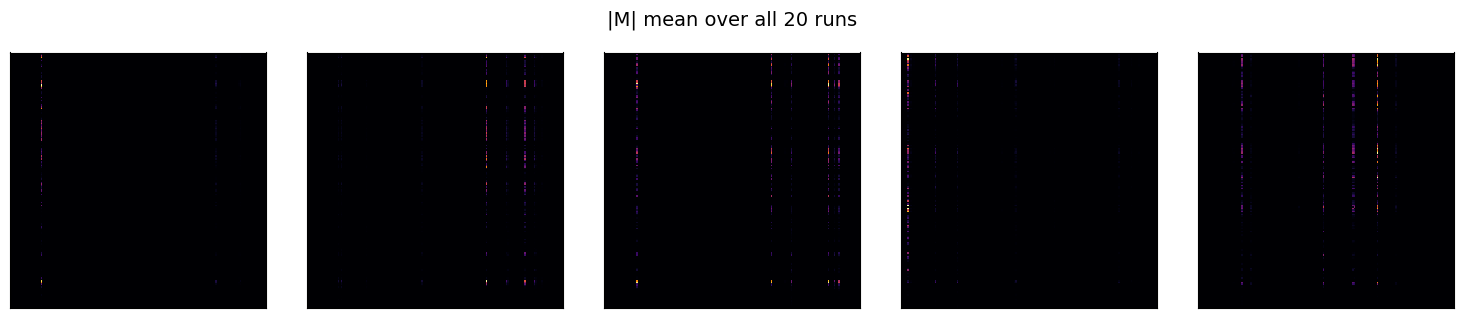

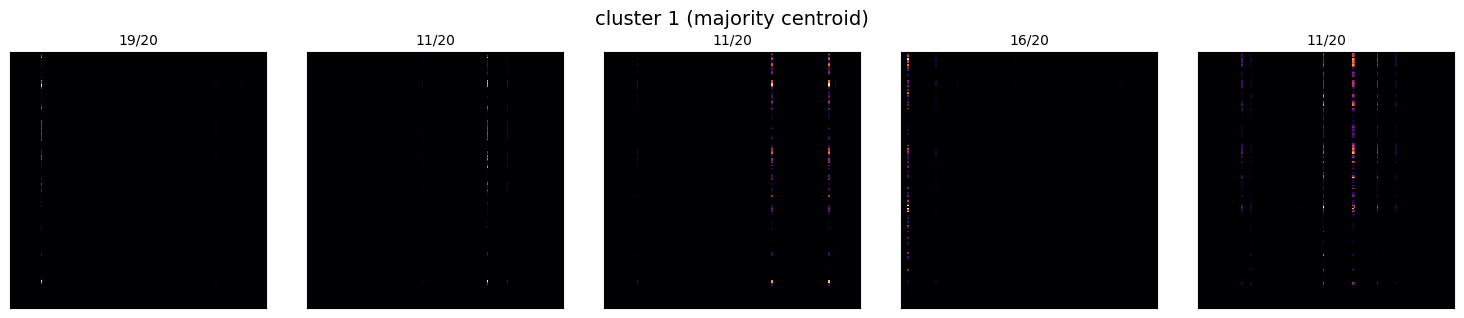

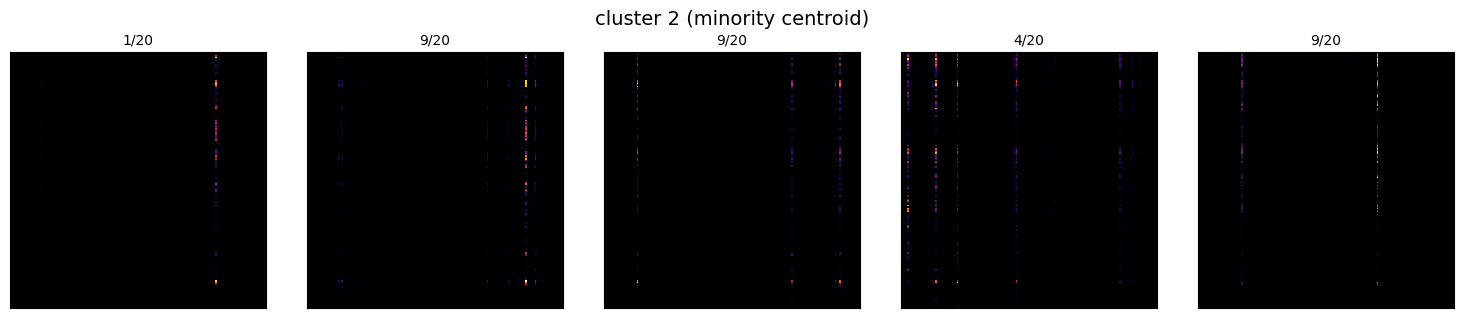

Saved:
   /Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_aal_2000-DECIFRA-vanilla/_images/clustered_separate_n20_row1_mean.svg
   /Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_aal_2000-DECIFRA-vanilla/_images/clustered_separate_n20_row2_majority.svg
   /Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_aal_2000-DECIFRA-vanilla/_images/clustered_separate_n20_row3_minority.svg


['/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_aal_2000-DECIFRA-vanilla/_images/clustered_separate_n20_row1_mean.svg',
 '/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_aal_2000-DECIFRA-vanilla/_images/clustered_separate_n20_row2_majority.svg',
 '/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_aal_2000-DECIFRA-vanilla/_images/clustered_separate_n20_row3_minority.svg']

In [23]:
# R1Q3 / R4Q2: AAL vanilla -- 3 separate row-figures, per-matrix support (scaled to 20)
test_data = load_dataset("ukb_aal")
exp_path = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_aal_2000-DECIFRA-vanilla"

# tip: set null_diagonal=True if a strong diagonal hides the off-diagonal structure
inspect_model_clustered_separate(
    exp_path, test_data,
    use_cache=False, n_samples=1, null_diagonal=False, total_models=20,
)

In [11]:
import os
import pandas as pd
import numpy as np

log_dir = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_aal_2000-DECIFRA-vanilla"
best_losses = []

# Iterate through all run folders
for run_id in sorted(os.listdir(log_dir)):
    run_path = os.path.join(log_dir, run_id)
    
    # Skip any non-directories or ignored folders like '_images' and 'excl'
    if not os.path.isdir(run_path) or run_id.startswith("_") or run_id == "excl":
        continue
        
    csv_path = os.path.join(run_path, "train_logs.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        if "val_forecast_loss" in df.columns:
            # Find the best (minimum) validation forecast loss for this run
            best_loss = df["val_forecast_loss"].min()
            best_losses.append(best_loss)

if best_losses:
    mean_loss = np.mean(best_losses)
    std_loss = np.std(best_losses)
    ratio = std_loss/mean_loss
    
    print(f"Number of models evaluated: {len(best_losses)}")
    print(f"Mean best val_forecast_loss: {mean_loss:.4f}")
    print(f"Std best val_forecast_loss:  {std_loss:.4f}")
    print(f"Ratio:  {ratio:.4f}")
else:
    print("No valid train_logs.csv files found.")


Number of models evaluated: 16
Mean best val_forecast_loss: 0.7268
Std best val_forecast_loss:  0.0061
Ratio:  0.0083


In [10]:
import os
import pandas as pd
import numpy as np

log_dir = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb_aal_2000-DECIFRA_MS-default"
best_losses = []

# Iterate through all run folders
for run_id in sorted(os.listdir(log_dir)):
    run_path = os.path.join(log_dir, run_id)
    
    # Skip any non-directories or ignored folders like '_images' and 'excl'
    if not os.path.isdir(run_path) or run_id.startswith("_") or run_id == "excl":
        continue
        
    csv_path = os.path.join(run_path, "train_logs.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        if "val_forecast_loss" in df.columns:
            # Find the best (minimum) validation forecast loss for this run
            best_loss = df["val_forecast_loss"].min()
            best_losses.append(best_loss)

if best_losses:
    mean_loss = np.mean(best_losses)
    std_loss = np.std(best_losses)
    ratio = std_loss/mean_loss
    
    print(f"Number of models evaluated: {len(best_losses)}")
    print(f"Mean best val_forecast_loss: {mean_loss:.4f}")
    print(f"Std best val_forecast_loss:  {std_loss:.4f}")
    print(f"Ratio:  {ratio:.4f}")
else:
    print("No valid train_logs.csv files found.")


Number of models evaluated: 20
Mean best val_forecast_loss: 0.6614
Std best val_forecast_loss:  0.0064
Ratio:  0.0097


In [14]:
import os
import pandas as pd
import numpy as np

log_dir = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb-DECIFRA_MS-default"
best_losses = []

# Iterate through all run folders
for run_id in sorted(os.listdir(log_dir)):
    run_path = os.path.join(log_dir, run_id)
    
    # Skip any non-directories or ignored folders like '_images' and 'excl'
    if not os.path.isdir(run_path) or run_id.startswith("_") or run_id == "excl":
        continue
        
    csv_path = os.path.join(run_path, "train_logs.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        if "val_forecast_loss" in df.columns:
            # Find the best (minimum) validation forecast loss for this run
            best_loss = df["val_forecast_loss"].min()
            best_losses.append(best_loss)

if best_losses:
    mean_loss = np.mean(best_losses)
    std_loss = np.std(best_losses)
    ratio = std_loss/mean_loss
    
    print(f"Number of models evaluated: {len(best_losses)}")
    print(f"Mean best val_forecast_loss: {mean_loss:.4f}")
    print(f"Std best val_forecast_loss:  {std_loss:.4f}")
    print(f"Ratio:  {ratio:.4f}")
else:
    print("No valid train_logs.csv files found.")


Number of models evaluated: 10
Mean best val_forecast_loss: 0.4151
Std best val_forecast_loss:  0.0008
Ratio:  0.0019


In [13]:
import os
import pandas as pd
import numpy as np

log_dir = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb-DECIFRA"
best_losses = []

# Iterate through all run folders
for run_id in sorted(os.listdir(log_dir)):
    run_path = os.path.join(log_dir, run_id)
    
    # Skip any non-directories or ignored folders like '_images' and 'excl'
    if not os.path.isdir(run_path) or run_id.startswith("_") or run_id == "excl":
        continue
        
    csv_path = os.path.join(run_path, "train_logs.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        if "val_forecast_loss" in df.columns:
            # Find the best (minimum) validation forecast loss for this run
            best_loss = df["val_forecast_loss"].min()
            best_losses.append(best_loss)

if best_losses:
    mean_loss = np.mean(best_losses)
    std_loss = np.std(best_losses)
    ratio = std_loss/mean_loss
    
    print(f"Number of models evaluated: {len(best_losses)}")
    print(f"Mean best val_forecast_loss: {mean_loss:.4f}")
    print(f"Std best val_forecast_loss:  {std_loss:.4f}")
    print(f"Ratio:  {ratio:.4f}")
else:
    print("No valid train_logs.csv files found.")


Number of models evaluated: 20
Mean best val_forecast_loss: 0.4790
Std best val_forecast_loss:  0.0027
Ratio:  0.0057


In [ ]:
MSE = 0.58 for ICA data and 1.14 for AAL_DATA
(MSE = 0.7268 ± 0.0061)
(MSE = 0.4151 ± 0.0008).

In [15]:
0.4151/0.58, 0.7268/1.14

(0.7156896551724139, 0.6375438596491229)